<div style="text-align: center; line-height: 1.35;">
  <h3><strong>UNIVERSIDAD TECNOLÓGICA DE PANAMÁ</strong></h3>
  <h3>FACULTAD DE INGENIERÍA DE SISTEMAS COMPUTACIONALES</h3>
  <h3>DEPARTAMENTO DE COMPUTACIÓN Y SIMULACIÓN DE SISTEMAS</h3>
  <hr style="margin: 24px 0;">
  <h1><strong>Taller Práctico N.° 2</strong></h1>
  <h2>Visualización Estadística con Seaborn</h2>
  <h3>Ciencia de Datos</h3>
</div>

<table>
  <tr><th>Campo</th><th>Información</th></tr>
  <tr><td><strong>Facilitador</strong></td><td>Dr. José Carlos Rangel Ortiz</td></tr>
  <tr><td><strong>Módulo</strong></td><td>Introducción a la Ciencia de Datos</td></tr>
  <tr><td><strong>Unidad</strong></td><td>Minería de Datos</td></tr>
  <tr><td><strong>Estudiante</strong></td><td><strong>Jhuomar Boskoll Barría Quintero | 9-766-196</strong></td></tr>
  <tr><td><strong>Herramientas</strong></td><td>Python, Pandas, Matplotlib y Seaborn</td></tr>
</table>


# Introducción

La visualización de datos es una fase esencial del análisis exploratorio, porque permite identificar patrones, relaciones, concentraciones, valores atípicos y posibles limitaciones en los datos antes de aplicar técnicas estadísticas o modelos predictivos. En este taller se utiliza **Seaborn**, una biblioteca de Python construida sobre Matplotlib que simplifica la creación de gráficos estadísticos claros, consistentes y adecuados para comunicar hallazgos.

El ejercicio se desarrolla con el dataset **Titanic**, disponible dentro de Seaborn. A partir de este conjunto de datos se exploran variables demográficas, económicas y de supervivencia mediante gráficos univariados, bivariados y matrices de correlación.

## Objetivos del taller

- Aplicar funciones de Seaborn para construir visualizaciones estadísticas a partir de un `DataFrame`.
- Reconocer el tipo de gráfico adecuado según la naturaleza de las variables analizadas.
- Interpretar distribuciones, relaciones entre variables y diferencias entre grupos.
- Presentar resultados visuales con un formato claro y académico.


# Preparación del entorno

Se importan las bibliotecas necesarias para el análisis. Seaborn se utiliza para construir las visualizaciones, Matplotlib para ajustes complementarios y el estilo `whitegrid` para mejorar la lectura de los ejes y las comparaciones visuales.


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
sns.set_style('whitegrid')


# Carga y contexto del dataset

El dataset `titanic` contiene información de pasajeros del Titanic. Para este taller se emplean principalmente las siguientes variables:

| Variable | Descripción |
|---|---|
| `survived` | Indica si el pasajero sobrevivió (`1`) o no (`0`). |
| `pclass` | Clase del boleto codificada numéricamente. |
| `sex` | Sexo del pasajero. |
| `age` | Edad del pasajero. |
| `fare` | Tarifa pagada por el boleto. |
| `class` | Clase del pasajero en formato categórico: First, Second o Third. |
| `adult_male` | Indica si el pasajero era un hombre adulto. |
| `alone` | Indica si el pasajero viajaba solo. |


In [2]:
titanic = sns.load_dataset('titanic')
titanic.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# Desarrollo de visualizaciones

A continuación se presentan las visualizaciones solicitadas en el taller. Cada gráfica incluye su propósito analítico, las variables utilizadas y una interpretación breve esperada.


## 1. Relación entre tarifa y edad

**Tipo de gráfico:** gráfico conjunto (`jointplot`).  
**Variables:** `fare` y `age`.  
**Objetivo analítico:** observar la relación entre la tarifa pagada y la edad de los pasajeros, junto con las distribuciones marginales de ambas variables.  
**Interpretación esperada:** la mayoría de las tarifas se concentra en valores bajos; existen valores atípicos con tarifas elevadas, y la edad se distribuye principalmente entre jóvenes y adultos.


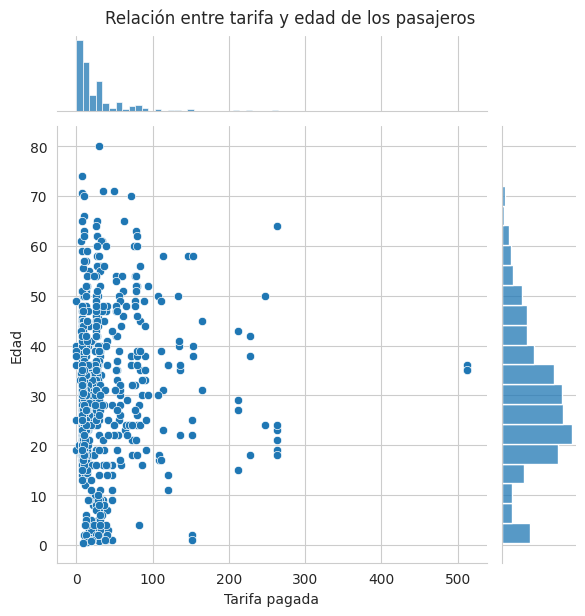

In [3]:
g = sns.jointplot(x='fare', y='age', data=titanic)
g.set_axis_labels('Tarifa pagada', 'Edad')
g.fig.suptitle('Relación entre tarifa y edad de los pasajeros', y=1.02)


## 2. Distribución de tarifas

**Tipo de gráfico:** histograma (`displot`).  
**Variable:** `fare`.  
**Objetivo analítico:** analizar la concentración y dispersión de las tarifas pagadas por los pasajeros.  
**Interpretación esperada:** la distribución presenta asimetría positiva; la mayoría de los pasajeros pagó tarifas bajas y pocos casos corresponden a tarifas muy altas.


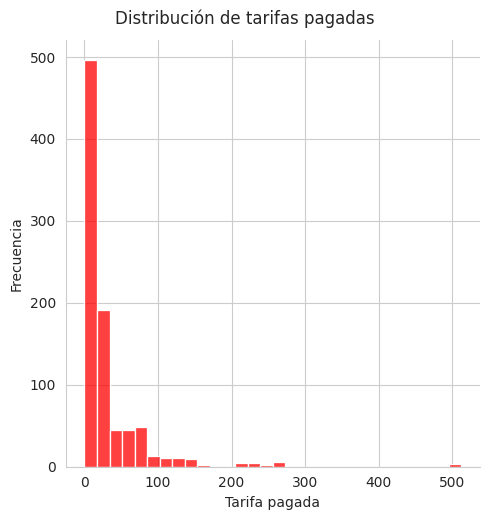

In [4]:
g = sns.displot(titanic['fare'], kde=False, color='red', bins=30)
g.set_axis_labels('Tarifa pagada', 'Frecuencia')
g.fig.suptitle('Distribución de tarifas pagadas', y=1.03)


## 3. Edad por clase de pasajero

**Tipo de gráfico:** diagrama de caja (`boxplot`).  
**Variables:** `class` y `age`.  
**Objetivo analítico:** comparar la distribución de edades entre las clases del barco.  
**Interpretación esperada:** la primera clase tiende a concentrar pasajeros de mayor edad, mientras que la tercera clase presenta una distribución más joven y con mayor dispersión.


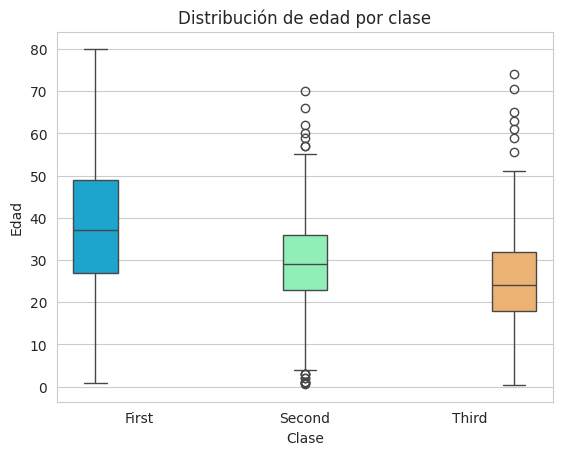

In [5]:
ax = sns.boxplot(x='class', y='age', data=titanic, palette='rainbow', hue='class', legend=False)
ax.set_title('Distribución de edad por clase')
ax.set_xlabel('Clase')
ax.set_ylabel('Edad')


## 4. Dispersión de edades por clase

**Tipo de gráfico:** gráfico de enjambre (`swarmplot`).  
**Variables:** `class` y `age`.  
**Objetivo analítico:** visualizar cada observación individual de edad dentro de cada clase, evitando la superposición de puntos.  
**Interpretación esperada:** la tercera clase concentra más pasajeros y muestra una mayor densidad de edades jóvenes; la primera clase tiene menos observaciones y edades relativamente más altas.


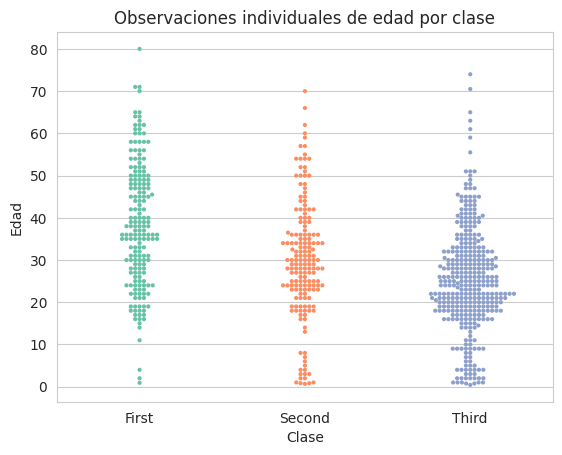

In [6]:
ax = sns.swarmplot(x='class', y='age', data=titanic, palette='Set2', hue='class', legend=False, size=3)
ax.set_title('Observaciones individuales de edad por clase')
ax.set_xlabel('Clase')
ax.set_ylabel('Edad')


## 5. Cantidad de pasajeros por sexo

**Tipo de gráfico:** gráfico de conteo (`countplot`).  
**Variable:** `sex`.  
**Objetivo analítico:** comparar la cantidad de pasajeros registrados según sexo.  
**Interpretación esperada:** el dataset contiene una mayor cantidad de pasajeros masculinos que femeninos.


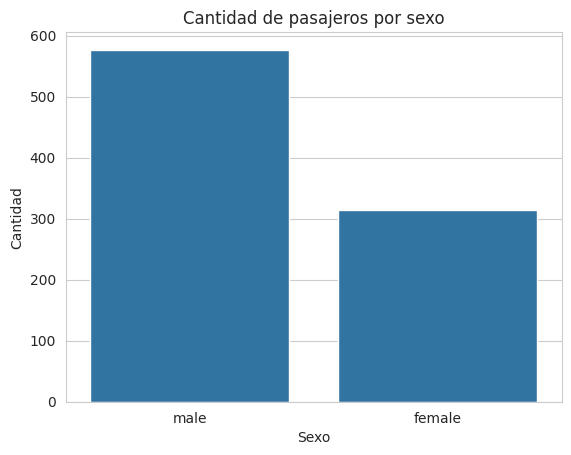

In [7]:
ax = sns.countplot(x='sex', data=titanic)
ax.set_title('Cantidad de pasajeros por sexo')
ax.set_xlabel('Sexo')
ax.set_ylabel('Cantidad')


## 6. Matriz de correlación

**Tipo de gráfico:** mapa de calor (`heatmap`).  
**Variables:** variables numéricas y booleanas del dataset.  
**Objetivo analítico:** identificar relaciones lineales entre variables como supervivencia, clase, edad, tarifa y composición familiar.  
**Interpretación esperada:** la supervivencia se relaciona de forma visible con variables como `adult_male`, `pclass` y `fare`; además, `sibsp` y `parch` muestran asociación por su vínculo con familiares a bordo.


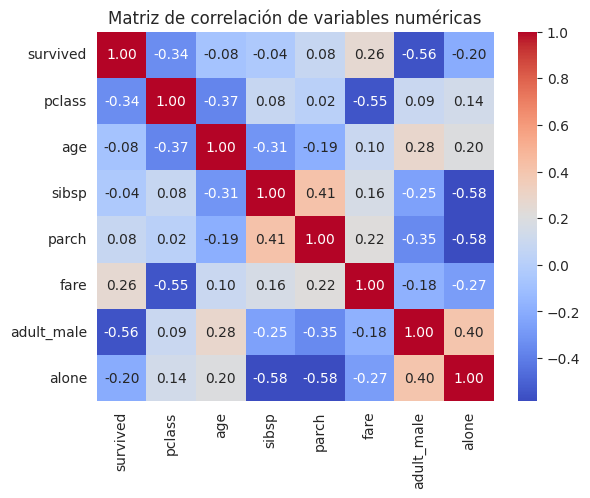

In [8]:
ax = sns.heatmap(titanic.corr(numeric_only=True), cmap='coolwarm', annot=True, fmt='.2f')
ax.set_title('Matriz de correlación de variables numéricas')


## 7. Distribución de edad por sexo

**Tipo de gráfico:** cuadrícula facetada (`FacetGrid`).  
**Variables:** `age` y `sex`.  
**Objetivo analítico:** comparar la distribución de edades entre hombres y mujeres mediante histogramas separados.  
**Interpretación esperada:** ambos grupos presentan concentración de pasajeros adultos jóvenes, con diferencias en el volumen total de observaciones debido a la mayor presencia de hombres en el dataset.


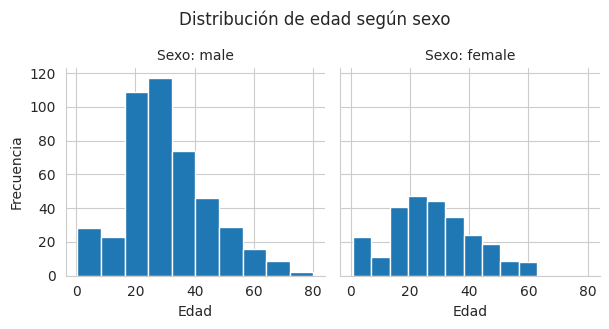

In [9]:
g = sns.FacetGrid(titanic, col='sex')
g.map(plt.hist, 'age')
g.set_axis_labels('Edad', 'Frecuencia')
g.set_titles('Sexo: {col_name}')
g.fig.suptitle('Distribución de edad según sexo', y=1.08)


# Conclusiones

El uso de Seaborn permitió representar de manera clara diferentes perspectivas del dataset Titanic. Los gráficos muestran que las tarifas presentan una distribución altamente asimétrica, con una concentración marcada en valores bajos y algunos valores extremos. También se observa que la edad varía según la clase del pasajero, con una tendencia de edades mayores en primera clase y una mayor concentración de pasajeros jóvenes en tercera clase.

El conteo por sexo evidencia una mayor presencia de pasajeros masculinos dentro del conjunto de datos. Por su parte, la matriz de correlación permite identificar asociaciones relevantes para el análisis exploratorio, especialmente entre supervivencia, clase, tarifa y la variable `adult_male`. Finalmente, la comparación de histogramas por sexo facilita observar diferencias en volumen y distribución de edades entre hombres y mujeres.

En conjunto, estas visualizaciones demuestran la utilidad de Seaborn para explorar datos categóricos, numéricos y relaciones estadísticas de forma ordenada, interpretable y adecuada para una presentación académica.
